## Lasso and Ridge Regression
What is regularization
- Technique use to prevent overfitting by adding a penalty term to the cost function of the regression model
  

- #### Types of Regularization
  - Ridge Regression (L2 Regularization)
    - Adds the sum of the squared coefficients to the cost function 
    - Ridge shrinks cofficients but does not eliminate them
  
  - Lasso Regression (L1 Regulasization)
    - Adds the sum of absolute coefficients to the const function
    - Encourages sparsity in the coefficients, effectively performing feature selection
    - Lasso can shrink some coefficients to zero, removing irrelevant features

#### Avoding Overfitting with Regularization
- Regularization reduces the risk of overfitting by controlling the complexity of the model
- The regularization parameter λ also called alpha, in some libearies plas a critical role
- A high λ value increases the penality, forcing smaller coefficients and reducing overfitting
- A low λ value allows the model to fit the training data more closely, increasing the risk of overfitting

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split

In [10]:
# Loading the california housing data
data = fetch_california_housing(as_frame = True)
df = data.frame

In [11]:
# sELECT FEATURE (Median Income) and target (Median House Value)
X = df[['MedInc']]
y = df[['MedHouseVal']]

In [12]:
# Transforom feature to polynomial feature
poly= PolynomialFeatures(degree=2, include_bias=False)
X_poly  = poly.fit_transform(X)

In [14]:
# Split data  into training and testing
X_train, X_test, y_train, y_test  = train_test_split(X_poly,y,test_size=0.2, random_state = 42)

In [21]:
# Ridge Regression 
ridge_model = Ridge(alpha=1)
ridge_model.fit(X_train, y_train)
ridge_prediction = ridge_model.predict(X_test)

In [25]:
# Evaluating Ridge Regression
ridge_mse = mean_squared_error(y_test, ridge_prediction)
print("Ridge MSE:",ridge_mse)

Ridge MSE: 0.703272792117919


In [17]:
lasso_model = Lasso(alpha = 0.1)
lasso_model.fit(X_train, y_train)
lasso_prediction = lasso_model.predict(X_test)

In [18]:
# Evaluating Lasso Regression
lasso_mse = mean_squared_error(y_test, lasso_prediction)
print("Lasso Regression MSE:", lasso_mse)

Lasso Regression MSE: 0.7211823140579732


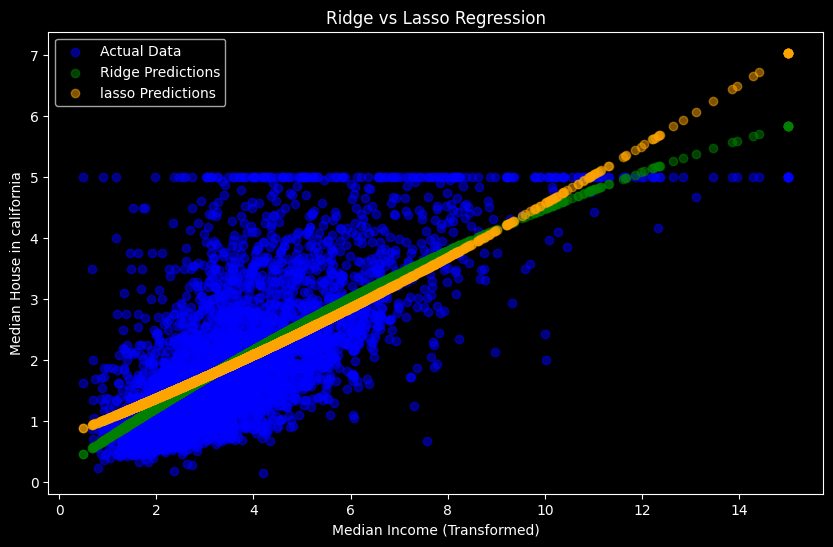

In [24]:
# Visualise Ridge vs Lasso Regression
plt.figure(figsize = (10,6))
plt.scatter(X_test[:,0], y_test, color="blue", label = "Actual Data", alpha = 0.5)
plt.scatter(X_test[:,0], ridge_prediction, color="green", label= "Ridge Predictions", alpha =0.5 )
plt.scatter(X_test[:,0], lasso_prediction, color="orange", label= "lasso Predictions", alpha =0.5 )
plt.title("Ridge vs Lasso Regression")
plt.xlabel("Median Income (Transformed)")
plt.ylabel("Median House in california")
plt.legend()
plt.show()

In [14]:
# Evaluate Model Performance
mse = mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 0.695037253723973
